# "Buy yesterday's losers" — real edge, or the bid-ask bounce? 🏓
### Why short-term mean reversion backtests like free money — and why it isn't, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

Here's a strategy that has tempted traders forever: stocks that **fell** yesterday tend to **bounce back** today, so buy the losers, sell the winners, and pocket the snap-back. And it's true — on a price chart it really does work, with a Sharpe most funds would envy.

But in **1984**, Richard Roll explained a trap hiding inside that chart. Stock prices don't trade at one clean number — they bounce between a slightly-lower **bid** and a slightly-higher **ask**. That bounce, all by itself, makes prices *look* like they mean-revert even when the real price is a pure coin-flip random walk. And you can't pocket it — because grabbing the bounce means **paying the very spread that creates it.**

This notebook shows the reversion is real-as-a-pattern and empty-as-a-strategy at the same time.

> 📓 **Plain-language layer.** Want Roll's identity, the bootstrap and the break-even math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Free data has no bid/ask quotes, so we **infer** the spread from the prices themselves (Roll's own estimator) and call it a proxy throughout. We test on **small-caps**, where spreads — and the bounce — are widest. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bid_ask_bounce import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    _R = data.load_real()
    NAMES = [c for c in _R.columns if c != "IWM"]
    RET = _R[NAMES]                                 # the small-cap return panel
else:
    RET = None
print("real small-cap cache present:", HAVE_REAL,
      "| names:", (0 if RET is None else RET.shape[1]),
      "| days:", (0 if RET is None else len(RET)))

def syn_panel(n_assets=30, n_days=4000, spread=0.004, edge=0.0, seed=377):
    """Synthetic panel of Roll assets sharing one spread/edge (cross-section for the book)."""
    cols = {f"A{j}": data.synthetic_roll(n_days=n_days, spread=spread, edge=edge,
                                         seed=seed + j)["r_obs"] for j in range(n_assets)}
    return pd.DataFrame(cols).dropna()

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-08-11', 'end': '2026-06-18', 'days': 5246, 'years': 20.9, 'n_names': 35, 'ac1': -0.065, 'roll_spread_bps': 109, 'book': [(0.0, 5.02, 54.7, 1.2, 5.47, 0.0), (5.0, -2.22, 47.5, -0.53, -2.42, 0.014), (10.0, -9.46, 41.2, -2.26, -10.31, 0.0), (20.0, -23.93, 29.7, -5.72, -26.08, 0.0)], 'gross_bps': 5.02, 'turnover': 1.45, 'be_half_bps': 3.47, 'be_round_bps': 6.93, 'ratio': 16, 'roll1': [(0.0, 1.3e-06, 0.0, 0.009, None), (0.005, -5e-06, -6.3e-06, -0.032, 0.0045), (0.01, -2.4e-05, -2.5e-05, -0.12, 0.0097), (0.02, -9.7e-05, -0.0001, -0.28, 0.0197)], 'roll2': [(0.0, 3.31, 7.5, -25.13, -56.9, -14.27), (-0.25, 39.58, 89.0, 8.01, 18.0, 4.51)]}


real small-cap cache present: True | names: 35 | days: 5246


## The answer first

| Question | Answer |
|---|---|
| Do stocks that fell yesterday bounce back? | **Yes — measurably.** Small-cap daily returns have a negative day-to-day correlation (**-0.065**), and a reversal book backtests at **Sharpe 1.2** before costs. |
| So it's free money? | **No.** That exact bounce-back is what a pure **bid-ask bounce** produces even with *no* real reversion. Roll's estimator reads a **~109 bps** spread out of the same number. |
| What happens after costs? | **It dies instantly.** The book breaks even at a **~7 bps** round-trip; the real spread is **~109 bps** — about **16× wider**. Net, the Sharpe is **-0.5**. |
| Then why does the chart look so good? | Because a backtest prints at the close and **never pays the bounce it's trading against.** The 'profit' *is* the spread. |

> The reversion is real. The edge is the spread you'd pay to grab it. Roll named this trap 40 years ago.

## 1 · The claim

> *"Short-term mean reversion is one of the most robust effects in markets. Yesterday's biggest losers snap back; yesterday's winners give some back. Go long the losers, short the winners, rebalance daily — the contrarian book just *works*."*

And the data agrees at first glance: daily stock returns are **negatively autocorrelated** — a down day is a touch more likely to be followed by an up day. The contrarian book harvests that. We'll rebuild it on real small-caps and watch it print a beautiful **gross** Sharpe… and then ask the only question that matters.

## 2 · So what?

A reliable, high-Sharpe, market-neutral daily strategy would be enormously valuable — it's the dream of every stat-arb desk. But there are **two** different things hiding inside "stocks mean-revert," and only one is worth money. (1) The *true, efficient* price genuinely tends to reverse — a real, harvestable edge. Or (2) the **price you see printed** wobbles between bid and ask, so it *looks* like it reverses even though the true price didn't move predictably at all. Case (2) is a mirage: the apparent profit is exactly the spread, and you pay that spread to trade. Telling the two apart is the whole game.

## 3 · How would we even know?

Roll gave us the test in 1984. **Build a world we control:** a true stock price that is a **pure random walk** — no reversion whatsoever — then make every trade print at the bid or the ask, a coin-flip each day. If the *observed* returns then look like they mean-revert, we've proven the bounce can fake the whole effect.

1. **Show the illusion.** On the synthetic price (zero real reversion) the bounce alone creates negative day-to-day correlation — and the size tells us the spread.
2. **Run the book on the real tape.** A daily reversal book on **35 small-caps**, measured **gross** and then **net** of a realistic spread.
3. **Find the break-even.** How small would the spread have to be for the book to make money? Compare that to the spread the data actually implies. If break-even is far below reality, the edge *is* the bounce.

## 4 · The teardown — let's actually look

**First, the illusion on data we control.** A *pure random-walk* stock (no reversion at all) plus a bid-ask bounce. Watch the day-to-day correlation go negative purely from the bounce — and grow as we widen the spread.

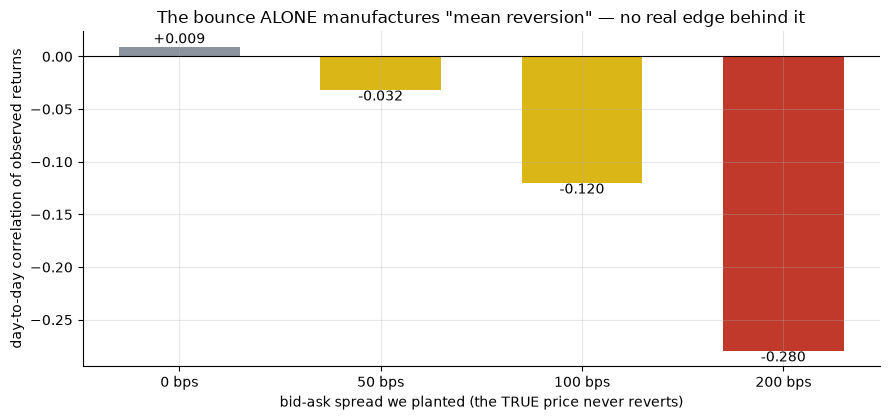

with NO spread the correlation is ~0 (true price is a random walk); add a bounce and it goes negative purely from microstructure.


In [2]:
spreads = [0.0, 0.005, 0.010, 0.020]
ac1 = []
for s in spreads:
    syn = data.synthetic_roll(spread=s, edge=0.0, seed=377)   # edge=0 => NO real reversion
    ac1.append(st.lag1_autocorr(syn['r_obs'].values))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([f'{s*1e4:.0f} bps' for s in spreads], ac1, color=[GREY,AMBER,AMBER,RED], width=.6)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('day-to-day correlation of observed returns')
ax.set_xlabel('bid-ask spread we planted (the TRUE price never reverts)')
ax.set_title('The bounce ALONE manufactures "mean reversion" — no real edge behind it')
for i,a in enumerate(ac1): ax.annotate(f'{a:+.3f}',(i,a),ha='center',va='top' if a<0 else 'bottom')
plt.tight_layout(); plt.show()
print('with NO spread the correlation is ~0 (true price is a random walk);',
      'add a bounce and it goes negative purely from microstructure.')

There it is. With **no** bounce the made-up stock shows **no** reversion (the true price is a coin-flip). Add a bid-ask bounce and the *observed* returns suddenly look mean-reverting — the wider the spread, the stronger the illusion. **Nothing about the real price changed.** Now the real-tape question: does a reversal book make money on actual small-caps?

**The reversal book on real small-caps — gross, then net of the spread.** Long yesterday's losers, short the winners, rebalanced daily, over 20 years.

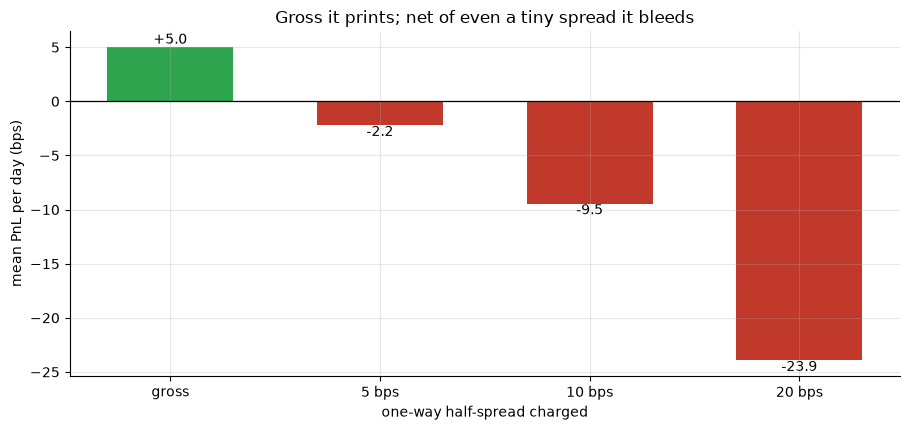

gross +5.0 bps/day; charge a 5 bps half-spread and it is already -2.2 bps


In [3]:
halfs = [0.0, 5.0, 10.0, 20.0]   # one-way half-spread in bps
if HAVE_REAL:
    means = [st.summarize_book(RET, cost_halfspread=h/1e4)['mean_bps'] for h in halfs]
else:
    means = [b[1] for b in R['book']]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [GREEN if m>0 else RED for m in means]
ax.bar([('gross' if h==0 else f'{h:.0f} bps') for h in halfs], means, color=cols, width=.6)
ax.axhline(0, c='k', lw=.9)
ax.set_ylabel('mean PnL per day (bps)'); ax.set_xlabel('one-way half-spread charged')
ax.set_title('Gross it prints; net of even a tiny spread it bleeds')
for i,m in enumerate(means): ax.annotate(f'{m:+.1f}',(i,m),ha='center',va='bottom' if m>0 else 'top')
plt.tight_layout(); plt.show()
print(f'gross +{means[0]:.1f} bps/day; charge a 5 bps half-spread and it is already {means[1]:+.1f} bps')

The leftmost bar — **gross** — is the dream: **+5.0 bps/day**, a **55%** daily win-rate, **Sharpe 1.2**. But charge a one-way half-spread of just **5 bps** (a 10 bps round-trip — *cheaper* than almost any small-cap quote) and the book is already **losing money**. The apparent alpha was sitting entirely inside the spread.

**The punchline — break-even vs reality.** How thin would the spread have to be for the book to break even, next to the spread the data itself implies?

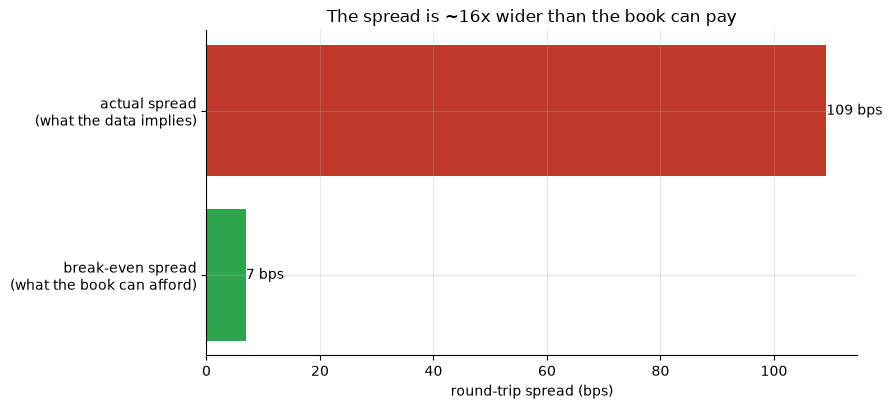

break-even ~7 bps round-trip vs an implied ~109 bps -> ~16x too wide


In [4]:
if HAVE_REAL:
    sig = -(RET.shift(1)); sig = sig.sub(sig.mean(axis=1), axis=0)
    gr = sig.abs().sum(axis=1); w = sig.div(gr.where(gr>0), axis=0).fillna(0.0)
    to = (w - w.shift(1)).abs().sum(axis=1).dropna().mean()
    gm = (w*RET).sum(axis=1).dropna().mean()
    be_round = (gm/to)*2*1e4
    roll_sp = st.avg_roll_spread(RET)*1e4
else:
    be_round = R['be_round_bps']; roll_sp = R['roll_spread_bps']
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.barh(['break-even spread\n(what the book can afford)','actual spread\n(what the data implies)'],
        [be_round, roll_sp], color=[GREEN, RED])
for i,v in enumerate([be_round, roll_sp]): ax.annotate(f'{v:.0f} bps', (v, i), va='center', ha='left')
ax.set_xlabel('round-trip spread (bps)')
ax.set_title(f'The spread is ~{roll_sp/be_round:.0f}x wider than the book can pay')
plt.tight_layout(); plt.show()
print(f'break-even ~{be_round:.0f} bps round-trip vs an implied ~{roll_sp:.0f} bps -> ~{roll_sp/be_round:.0f}x too wide')

That gap is the verdict. The book breaks even at a **~7 bps** round-trip; the spread you'd actually cross is **~109 bps** — about **16× wider**. There is no clever execution that closes a gap that big. The reversion *is* the bid-ask bounce, and you can't grab a bounce without paying the spread that makes it.

## 5 · The verdict

- **Signal — Weak.** The reversion is genuinely there in the numbers (gross Sharpe **1.2**, correlation **-0.065**) — but it's the *mechanical* footprint of the bounce, not a forecast of the real price. Real-as-a-statistic, not a clean edge.
- **Tradability — Mirage.** Net of any realistic spread it's a **loser** (Sharpe **-0.5** at a 10 bps round-trip). Break-even is **~16×** thinner than the real spread. There's no strategy here.
- **Free lunch? — Busted.** The chart looks like money only because the backtest never pays the bounce. Roll (1984) called it: short-term "mean reversion" is largely the bid-ask bounce in disguise.

## 6 · Could you actually trade it? — the one test that settles it

Forget statistics for a second. We *built* a world where we know the truth, and asked the book to make money in it. Two versions: one where the reversion is **pure bounce** (no real edge), one where we **plant a genuine** reversion. Only one should survive the spread.

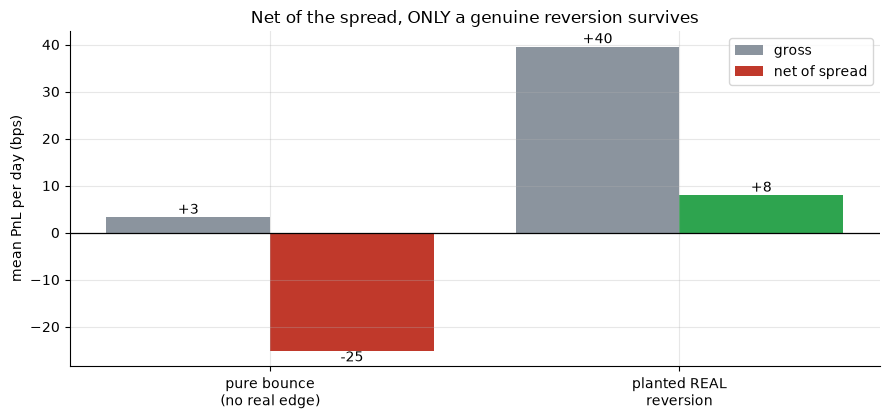

pure-bounce world: gross looks positive, NET is deeply negative — no edge to harvest.
planted-reversion world: net stays POSITIVE — a real edge survives the spread.


In [5]:
rows = []
for edge in (0.0, -0.25):
    P = syn_panel(spread=0.004, edge=edge)            # 40 bps round-trip world
    g = st.summarize_book(P, 0.0); n = st.summarize_book(P, 0.002)  # 20 bps half-spread
    rows.append((edge, g['mean_bps'], n['mean_bps']))
labels = ['pure bounce\n(no real edge)', 'planted REAL\nreversion']
x = np.arange(2); gr = [r[1] for r in rows]; nt = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-.2, gr, .4, color=GREY, label='gross')
ax.bar(x+.2, nt, .4, color=[RED if v<0 else GREEN for v in nt], label='net of spread')
ax.axhline(0, c='k', lw=.9); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('mean PnL per day (bps)')
ax.set_title('Net of the spread, ONLY a genuine reversion survives'); ax.legend()
for i,(g_,n_) in enumerate(zip(gr,nt)):
    ax.annotate(f'{g_:+.0f}',(i-.2,g_),ha='center',va='bottom')
    ax.annotate(f'{n_:+.0f}',(i+.2,n_),ha='center',va='bottom' if n_>0 else 'top')
plt.tight_layout(); plt.show()
print('pure-bounce world: gross looks positive, NET is deeply negative — no edge to harvest.')
print('planted-reversion world: net stays POSITIVE — a real edge survives the spread.')

This is the cleanest way to see it. In the **pure-bounce** world the book still shows a positive *gross* number — and then bleeds out **net of the spread**, because there was never anything to catch. Only when we plant a **real** reversion does the book stay **net-positive**. The real small-cap tape behaves like the *first* column: gross-positive, net-negative. That's the diagnosis.

## 7 · Going further 🚪

- **The slower cousin.** [Study 329 — One-Month-Reversal](../../329-one-month-reversal/) asks the same question one frequency down: does the *monthly* reversal premium survive costs, or is it the same trap with a longer fuse?
- **The illiquidity it lives in.** [Study 140 — Amihud-Illiquidity](../../140-amihud-illiquidity/) — short-term reversal is strongest exactly in the illiquid names where the bounce is biggest. That's not a coincidence.
- **Build your own.** Swap the small-cap basket for liquid mega-caps and re-run: the bounce shrinks, the gross Sharpe shrinks with it, and the illusion fades — more proof it was microstructure all along.

*Think you can harvest the reversion net of the spread? Show the reversal book landing **net-positive** on a tape where the spread is honestly charged — then we'll talk.*